# 01 — Priprema podataka i analiza strukture grafa

Prva sveska u nizu (redosled pregleda: `01` → `07`). Ovde:

1. preuzimamo skup podataka (**web-Stanford**, SNAP),
2. gradimo usmereni graf i retku (sparse) matricu susedstva,
3. analiziramo osnovnu strukturu grafa — stepene čvorova, (ne)povezanost, "dangling" čvorove — jer ova svojstva direktno utiču na ponašanje PageRank-a, HITS-a i SALSA-e (npr. čvorovi bez izlaznih grana su problem za PageRank; broj komponenti povezanosti je bitan za HITS-ovo "rich-get-richer" ponašanje),
4. čuvamo obrađeni graf u `data/processed/`, da ga naredne sveske (`02`–`05`) učitavaju brzo, bez ponovnog parsiranja ~2.3M linija teksta.

Detaljan opis dataset-a, motivacija za izbor i literatura nalaze se u glavnom `README.md`.

In [1]:
# --- Osnovni importi i podešavanje putanja ---
import gzip
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import requests

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
SLIKE_DIR = PROJECT_ROOT / "slike"

for d in (DATA_RAW, DATA_PROCESSED, SLIKE_DIR):
    d.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Snima figuru u slike/<name> (koriste se kasnije u dokumentaciji/prezentaciji)."""
    path = SLIKE_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Sačuvano: {path.relative_to(PROJECT_ROOT)}")


# --- Stilizacija grafika (fiksna, konzistentna paleta kroz ceo projekat) ---
PALETTE = {
    "pagerank": "#2a78d6",   # plava
    "hits":     "#eb6834",   # narandžasta
    "salsa":    "#1baf7a",   # tirkizna
    "baseline": "#eda100",   # žuta — in/out-degree baseline
}
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]  # sekvencijalna (magnituda)
DIVERGING = {"neg": "#e34948", "pos": "#2a78d6", "mid": "#f0efec"}  # divergentna (korelacije, -1..1)

INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

## 1. Preuzimanje dataset-a

Koristimo graf **web-Stanford** sa [SNAP](https://snap.stanford.edu/data/web-Stanford.html) — usmereni graf hiperlinkova sa domena stanford.edu (281.903 čvora, 2.312.497 grana, prikupljen 2002). Fajl se preuzima samo jednom i čuva lokalno u `data/raw/`.

In [2]:
DATA_URL = "https://snap.stanford.edu/data/web-Stanford.txt.gz"
RAW_GZ = DATA_RAW / "web-Stanford.txt.gz"
RAW_TXT = DATA_RAW / "web-Stanford.txt"

if not RAW_TXT.exists():
    if not RAW_GZ.exists():
        print(f"Preuzimam dataset sa {DATA_URL} ...")
        response = requests.get(DATA_URL, timeout=60)
        response.raise_for_status()
        RAW_GZ.write_bytes(response.content)
    with gzip.open(RAW_GZ, "rb") as f_in, open(RAW_TXT, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print(f"Dataset spreman: {RAW_TXT.relative_to(PROJECT_ROOT)}  ({RAW_TXT.stat().st_size / 1e6:.1f} MB)")

Dataset spreman: data\raw\web-Stanford.txt  (32.9 MB)


## 2. Učitavanje grana i matrica susedstva

Graf učitavamo kao listu grana, preslikavamo originalne ID-jeve čvorova na uzastopne indekse `0..n-1`, i gradimo *sparse* matricu susedstva `A` (`A[i, j] = 1` ako postoji grana `i → j`). Sparse format je neophodan — gusta matrica bi za 281.903 čvora zahtevala oko 317 GB memorije, dok retka čuva samo ~2.3M nenula elemenata.

Isto kao u originalnom radu (Najork, sekcija 3), eliminišemo duplirane grane između istog para čvorova.

In [3]:
edges_df = pd.read_csv(
    RAW_TXT, sep="\t", comment="#", names=["src", "dst"], dtype=np.int64,
)

nodes = np.union1d(edges_df["src"].to_numpy(), edges_df["dst"].to_numpy())
n = len(nodes)

rows = np.searchsorted(nodes, edges_df["src"].to_numpy())
cols = np.searchsorted(nodes, edges_df["dst"].to_numpy())
data = np.ones(len(edges_df), dtype=np.float64)

A = sp.csr_matrix((data, (rows, cols)), shape=(n, n))
A.sum_duplicates()   # spoji duplirane grane (i -> j) u jednu
A.data[:] = 1.0       # graf je bez težina

print(f"Učitano redova (sirovih grana): {len(edges_df):,}")
print(f"Čvorova: {n:,}")
print(f"Jedinstvenih grana: {A.nnz:,}")

Učitano redova (sirovih grana): 2,312,497
Čvorova: 281,903
Jedinstvenih grana: 2,312,497


## 3. Osnovna struktura grafa

Pre pokretanja algoritama za rangiranje, bitno je razumeti osnovna svojstva grafa — jer direktno objašnjavaju kako se PageRank, HITS i SALSA ponašaju:

- **"dangling" čvorovi** (out-degree = 0) su problem za PageRank (nemaju kome da "prenesu" skor) — standardno rešenje je ravnomerna redistribucija njihove mase (obrađujemo u `02_pagerank.ipynb`).
- **čvorovi sa in-degree = 0** dobijaju autoritet/PageRank skor 0 (nema ko da ih "preporuči").
- **broj komponenti povezanosti** je bitan jer je HITS matematički power-iteracija ka glavnom sopstvenom vektoru — na grafu sa više komponenti sklon je da sav skor "odnese" najveća/najgušća komponenta (videti hipoteze H1/H2 u `README.md`).

In [4]:
out_degree = np.asarray(A.sum(axis=1)).flatten()
in_degree = np.asarray(A.sum(axis=0)).flatten()

summary = pd.Series({
    "broj čvorova": n,
    "broj grana": int(A.nnz),
    "gustina (m / n(n-1))": A.nnz / (n * (n - 1)),
    "prosečan out-degree": round(out_degree.mean(), 2),
    "prosečan in-degree": round(in_degree.mean(), 2),
    "max out-degree": int(out_degree.max()),
    "max in-degree": int(in_degree.max()),
    "čvorovi sa out-degree = 0 (dangling)": int((out_degree == 0).sum()),
    "čvorovi sa in-degree = 0": int((in_degree == 0).sum()),
}, name="vrednost")
summary

broj čvorova                            2.819030e+05
broj grana                              2.312497e+06
gustina (m / n(n-1))                    2.909935e-05
prosečan out-degree                     8.200000e+00
prosečan in-degree                      8.200000e+00
max out-degree                          2.550000e+02
max in-degree                           3.860600e+04
čvorovi sa out-degree = 0 (dangling)    1.720000e+02
čvorovi sa in-degree = 0                2.031500e+04
Name: vrednost, dtype: float64

## 4. Povezanost grafa

Računamo broj **slabo** povezanih komponenti (ignorišući smer grana) i **jako** povezanih komponenti (poštujući smer), i veličinu najveće komponente u oba slučaja.

In [5]:
n_weak, labels_weak = connected_components(A, connection="weak")
size_largest_weak = np.bincount(labels_weak).max()

n_strong, labels_strong = connected_components(A, connection="strong")
size_largest_strong = np.bincount(labels_strong).max()

print(f"Slabo povezane komponente: {n_weak:,}  |  najveća: {size_largest_weak:,} čvorova ({size_largest_weak/n:.1%})")
print(f"Jako povezane komponente: {n_strong:,}  |  najveća: {size_largest_strong:,} čvorova ({size_largest_strong/n:.1%})")

Slabo povezane komponente: 365  |  najveća: 255,265 čvorova (90.6%)
Jako povezane komponente: 29,914  |  najveća: 150,532 čvorova (53.4%)


## 5. Distribucija stepena čvorova

Web grafovi tipično imaju *power-law* (skoro-linearnu na log-log skali) distribuciju stepena — provera ovog svojstva je standardni deo analize strukture skupa podataka.

Sačuvano: slike\f1_stepen_distribucija.png


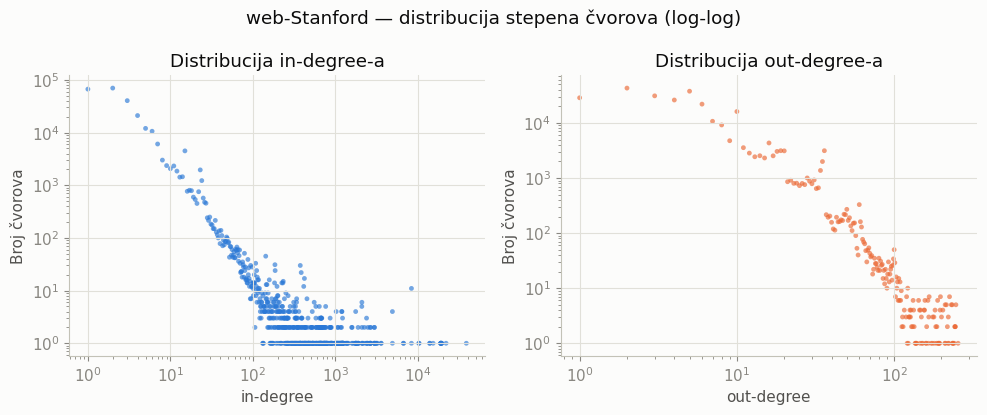

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

for ax, deg, label, color in zip(
    axes, [in_degree, out_degree], ["in-degree", "out-degree"], [PALETTE["pagerank"], PALETTE["hits"]]
):
    vals, counts = np.unique(deg[deg > 0], return_counts=True)
    ax.scatter(vals, counts, s=12, alpha=0.65, color=color, edgecolor="none")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(label)
    ax.set_ylabel("Broj čvorova")
    ax.set_title(f"Distribucija {label}-a")

fig.suptitle("web-Stanford — distribucija stepena čvorova (log-log)")
fig.tight_layout()
save_fig(fig, "f1_stepen_distribucija.png")
plt.show()

## 6. Čuvanje obrađenog grafa

Da naredne sveske (`02`–`05`) ne bi morale iznova da parsiraju ~2.3M redova teksta, čuvamo:

- retku matricu susedstva `A` → `data/processed/web-stanford_adjacency.npz`
- mapiranje indeks → originalni ID čvora → `data/processed/web-stanford_nodes.npy` (radi vraćanja na originalne ID-jeve pri interpretaciji rezultata)

In [7]:
sp.save_npz(DATA_PROCESSED / "web-stanford_adjacency.npz", A)
np.save(DATA_PROCESSED / "web-stanford_nodes.npy", nodes)

print(f"Sačuvano: {(DATA_PROCESSED / 'web-stanford_adjacency.npz').relative_to(PROJECT_ROOT)}")
print(f"Sačuvano: {(DATA_PROCESSED / 'web-stanford_nodes.npy').relative_to(PROJECT_ROOT)}")

Sačuvano: data\processed\web-stanford_adjacency.npz
Sačuvano: data\processed\web-stanford_nodes.npy


## Zaključci — Faza 1

**Osnovne brojke.** Graf ima **281.903 čvora** i **2.312.497 grana** — bez dupliranih grana (SNAP dataset ih je već očistio, `len(edges_df) == A.nnz`). Gustina je izuzetno niska (≈ 2,91 × 10⁻⁵), tipično za web grafove: svaki čvor je u proseku povezan sa svega **8,2** druga čvora, naspram 281.902 mogućih.

**Distribucija stepena** (slika `f1_stepen_distribucija.png`) potvrđuje očekivano *power-law* ponašanje — velika većina čvorova ima mali stepen, dok mali broj "hub"/"authority" čvorova dominira. Posebno je upečatljiva asimetrija: **max in-degree = 38.606**, dok je **max out-degree tek 255**. Ova asimetrija (neki čvorovi su masovno citirani, ali nijedan nije masovno "citirajući") je upravo ono što HITS i SALSA pokušavaju da uhvate razdvajanjem hub i autoritet uloge — kod PageRank-a ta razlika ne postoji (jedan skor po čvoru).

**"Dangling" čvorovi.** Samo 172 čvora (0,06%) nema izlaznih grana — zanemarljivo mali udeo; PageRank implementacija u `02_pagerank.ipynb` će ih obraditi standardnom redistribucijom mase. Nasuprot tome, **20.315 čvorova (7,2%)** nema ulaznih grana — ovi čvorovi će nužno dobiti autoritet/PageRank skor ≈ 0 kod sva tri algoritma, jer ih niko "ne preporučuje".

**Povezanost — "bowtie" struktura weba.** Graf je pretežno jedna slaba komponenta (**90,6%** čvorova), ali jako povezana komponenta (SCC) obuhvata samo **53,4%** čvorova, uz čak 29.914 sitnih SCC-ova. Ovo je poznata "bowtie" struktura web grafova [7]: veliko jezgro međusobno dostižnih stranica, plus delovi dostižni samo u jednom smeru (ulazni/izlazni "režnjevi") i izolovani "repovi".

**Zašto je ovo bitno za H1/H2 (iz README-a).** Graf *nije* jedna savršeno povezana komponenta — postoji 365 slabih komponenti. To je relevantno jer je HITS matematički power-iteracija ka glavnom sopstvenom vektoru: teorijski može dati skor ≈ 0 čitavim manjim komponentama, dok PageRank to izbegava po konstrukciji (damping/teleportacija garantuje da svaki čvor dobije nenula udeo). Ovo je konkretna, merljiva razlika koju testiramo u `05_poredjenje_algoritama.ipynb`, kada uporedimo koliko čvorova svaki algoritam "ugasi" na nulu.

**Sledeći korak:** `02_pagerank.ipynb` — implementacija i validacija PageRank-a nad ovim istim grafom.
